# Ex5 — Eran Rehani` 207823063
## Runge-Kutta ODE Solver with Adaptive Step Control

Baseball pitch trajectory and method benchmarking using adaptive RK3/RK4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Unit conversions
MPH_TO_MS   = 0.44704           # mph → m/s
FT_TO_M     = 0.3048            # feet → m
RPM_TO_RADS = 2 * np.pi / 60    # rpm → rad/s

# Physical constants
g      = 9.8                    # m/s²
B      = 4.1e-4                 # Magnus coefficient
DIST_X = 60 * FT_TO_M          # 18.288 m, pitcher-to-batter

# Typical throw parameters (shared across parts 4-6)
OMEGA = 1800 * RPM_TO_RADS      # spin rate [rad/s]
THETA = 1.0                     # elevation angle [°]

---
## Part 1: Runge-Kutta Solver with Adaptive Step Control

### Formulas

**RK3 (Kutta's third-order):**
$$k_1 = f(t,y),\quad k_2 = f\!\left(t+\tfrac{h}{2},\,y+\tfrac{h}{2}k_1\right),\quad k_3 = f(t+h,\,y-hk_1+2hk_2)$$
$$y_{n+1} = y_n + \frac{h}{6}(k_1 + 4k_2 + k_3)$$

**RK4 (classical fourth-order):**
$$k_1=f(t,y),\; k_2=f\!\left(t+\tfrac{h}{2},y+\tfrac{h}{2}k_1\right),\; k_3=f\!\left(t+\tfrac{h}{2},y+\tfrac{h}{2}k_2\right),\; k_4=f(t+h,y+hk_3)$$
$$y_{n+1} = y_n + \frac{h}{6}(k_1+2k_2+2k_3+k_4)$$

### Step-Doubling Error Control

For order-$p$ method, local truncation error $\sim Ch^{p+1}$:
- **Full step** $h$: error $\approx Ch^{p+1}$
- **Two half-steps** $h/2$: error $\approx Ch^{p+1}/2^p$

The difference $\delta = |y_\text{half}-y_\text{full}|$ estimates the local error.
Step is **accepted** if $\delta \le \varepsilon_\text{tol}$.

### Richardson Extrapolation

$$y_\text{best} = y_\text{half} + \frac{y_\text{half} - y_\text{full}}{2^p - 1}$$

gives a $(p+1)$-order accurate result.

### Step-Size Control

$$h_\text{new} = h \cdot \text{clamp}\!\left(0.9\left(\frac{\varepsilon_\text{tol}}{\delta}\right)^{1/(p+1)},\; 0.1,\; 2\right)

In [2]:
def rk_step(f, t, y, h, order):
    """Single RK step (order 3 or 4). Returns (y_new, n_fcalls)."""
    y = np.asarray(y, dtype=float)
    if order == 3:
        k1 = f(t,         y)
        k2 = f(t + h/2,   y + (h/2)*k1)
        k3 = f(t + h,     y - h*k1 + 2*h*k2)
        return y + (h/6)*(k1 + 4*k2 + k3), 3
    else:  # order == 4
        k1 = f(t,         y)
        k2 = f(t + h/2,   y + (h/2)*k1)
        k3 = f(t + h/2,   y + (h/2)*k2)
        k4 = f(t + h,     y + h*k3)
        return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4), 4


def rk_adaptive(f, t0, y0, t_end, tol, order, return_trajectory=False):
    """Adaptive RK with step-doubling + Richardson extrapolation.

    Returns (y_final, n_steps, n_fcalls)
    or (ts, ys, n_steps, n_fcalls) when return_trajectory=True.
    """
    if order not in (3, 4):
        raise ValueError("order must be 3 or 4")
    t = t0
    y = np.asarray(y0, dtype=float).copy()
    h = (t_end - t0) / 100.0
    n_steps = 0
    n_fcalls = 0
    scale = 2**order - 1        # Richardson denominator

    if return_trajectory:
        ts_list = [t]
        ys_list = [y.copy()]

    while t < t_end:
        h = min(h, t_end - t)

        y_full, nc1 = rk_step(f, t,       y,    h,   order)
        y_mid,  nc2 = rk_step(f, t,       y,    h/2, order)
        y_half, nc3 = rk_step(f, t + h/2, y_mid, h/2, order)
        n_fcalls += nc1 + nc2 + nc3

        err = np.max(np.abs(y_half - y_full))

        if err == 0.0 or err <= tol:
            y = y_half + (y_half - y_full) / scale
            t += h
            n_steps += 1
            if return_trajectory:
                ts_list.append(t)
                ys_list.append(y.copy())
            if err > 0:
                h *= min(2.0, 0.9 * (tol / err) ** (1.0 / (order + 1)))
        else:
            h *= max(0.1, 0.9 * (tol / err) ** (1.0 / (order + 1)))

    if return_trajectory:
        return np.array(ts_list), np.array(ys_list), n_steps, n_fcalls
    return y, n_steps, n_fcalls

---
## Part 2: Verification on Known ODE

Test on $y'(t) = -y(t)$, $y(0)=1$, exact solution $y(t)=e^{-t}$.

Integrate from $t=0$ to $t=5$ and compare to $e^{-5}$.

In [3]:
def decay_rhs(t, y):
    return -y

y_exact = np.exp(-5.0)
print(f"{'Order':>7} {'tol':>10} {'y(5)':>20} {'|error|':>14} {'steps':>7} {'f-calls':>9}")
print("-" * 72)
for order in (3, 4):
    for tol in (1e-3, 1e-6, 1e-9):
        y_num, ns, nf = rk_adaptive(decay_rhs, 0.0, np.array([1.0]), 5.0, tol, order)
        err = abs(y_num[0] - y_exact)
        print(f"{order:>7} {tol:>10.0e} {y_num[0]:>20.14f} {err:>14.4e} {ns:>7d} {nf:>9d}")

  Order        tol                 y(5)        |error|   steps   f-calls
------------------------------------------------------------------------
      3      1e-03     0.00676011752024     2.2171e-05      12       108
      3      1e-06     0.00673798080926     3.3810e-08      46       414
      3      1e-09     0.00673794704052     4.1430e-11     249      2250
      4      1e-03     0.00672943721461     8.5098e-06      10       120
      4      1e-06     0.00673793455122     1.2448e-08      24       288
      4      1e-09     0.00673794698317     1.5913e-11      86      1044


---
## Part 3: Step-Count Benchmark — Sum of Gaussians

$$\frac{dy(x)}{dx} = \sum_{i=1}^{5} \frac{1}{a\sqrt{\pi}}\, e^{-(x-b_i)^2/a^2}, \quad a=0.1,\; b_i\in\{-5,-1,1,4,7\}$$

Initial condition $y(-10)=0$; integrate to $x=10$.
Each term is approximately a unit delta function, so $y(10)\approx 5$.
The relative error is computed assuming the exact answer is $5$.

In [4]:
_B_VALS = [-5, -1, 1, 4, 7]
_A = 0.1

def gaussian_sum_rhs(x, y):
    total = sum(np.exp(-((x - b) / _A)**2) for b in _B_VALS)
    return np.array([total / (_A * np.sqrt(np.pi))])

TRUE_VAL = 5.0
print(f"{'RK order':>10} {'Req. acc':>12} {'No. steps':>11} {'No. f-calls':>13} {'Rel. error':>13}")
print("-" * 63)
for order in (3, 4):
    for tol in (1e-3, 1e-5, 1e-7, 1e-9):
        y_num, ns, nf = rk_adaptive(gaussian_sum_rhs, -10.0, np.array([0.0]), 10.0, tol, order)
        rel_err = abs(y_num[0] - TRUE_VAL) / TRUE_VAL
        print(f"{order:>10} {tol:>12.0e} {ns:>11d} {nf:>13d} {rel_err:>13.4e}")

  RK order     Req. acc   No. steps   No. f-calls    Rel. error
---------------------------------------------------------------
         3        1e-03          79           918    1.2082e-05
         3        1e-05         143          1719    7.4000e-07
         3        1e-07         274          3195    2.6456e-08
         3        1e-09         583          6147    9.4128e-10
         4        1e-03          77          1236    4.1533e-05
         4        1e-05         134          2028    1.7422e-06
         4        1e-07         277          4116    8.2514e-10
         4        1e-09         586          7968    4.1948e-11


---
## Baseball Trajectory: Physics

**Coordinate system:** $x$ — pitcher to batter, $y$ — horizontal, $z$ — vertical.

**Equations of motion:**
$$\frac{dv_x}{dt} = -F(v)\,v\,v_x + B\omega(v_z\sin\varphi - v_y\cos\varphi)$$
$$\frac{dv_y}{dt} = -F(v)\,v\,v_y + B\omega\,v_x\cos\varphi$$
$$\frac{dv_z}{dt} = -g - F(v)\,v\,v_z - B\omega\,v_x\sin\varphi$$

where $v=\sqrt{v_x^2+v_y^2+v_z^2}$, drag $F(v)=0.0039+\dfrac{0.0058}{1+e^{(v-35)/5}}$,
$B=4.1\times10^{-4}$, $\omega$ = spin [rad/s], $\varphi$ = spin-axis azimuth in $(y,z)$ plane.

**Initial conditions:** $x_0=y_0=z_0=0$, $v_{x0}=v_0\cos\theta$, $v_{y0}=0$, $v_{z0}=v_0\sin\theta$.

**Final time:** $t_f = (60\,\text{ft}) / v_0$.

| Pitch | $v_0$ | $\varphi$ |
|---|---|---|
| Curveball (RH pitcher) | 85 mph | 45° |
| Fastball (RH pitcher) | 95 mph | 225° |

In [5]:
def baseball_rhs(t, state, omega, phi):
    """RHS of baseball EOM. state = [x, y, z, vx, vy, vz]."""
    _, _, _, vx, vy, vz = state
    v = np.sqrt(vx**2 + vy**2 + vz**2)
    Fv = 0.0039 + 0.0058 / (1.0 + np.exp((v - 35.0) / 5.0))
    ax = -Fv*v*vx + B*omega*(vz*np.sin(phi) - vy*np.cos(phi))
    ay = -Fv*v*vy + B*omega*vx*np.cos(phi)
    az = -g - Fv*v*vz - B*omega*vx*np.sin(phi)
    return np.array([vx, vy, vz, ax, ay, az])

def baseball_ic(v0_mph, theta_deg=THETA):
    v0 = v0_mph * MPH_TO_MS
    th = np.radians(theta_deg)
    return np.array([0.0, 0.0, 0.0, v0*np.cos(th), 0.0, v0*np.sin(th)])

def baseball_tend(v0_mph):
    return DIST_X / (v0_mph * MPH_TO_MS)

---
## Part 4: Curveball Trajectory

$v_0 = 85\,\text{mph}$, $\varphi = 45°$, $\omega = 1800\,\text{rpm}$.  Solved with RK4, tolerance $10^{-9}$.

Curveball: 14 steps, 168 f-calls
Final: x=17.293 m | y=22.32 cm | z=-101.47 cm


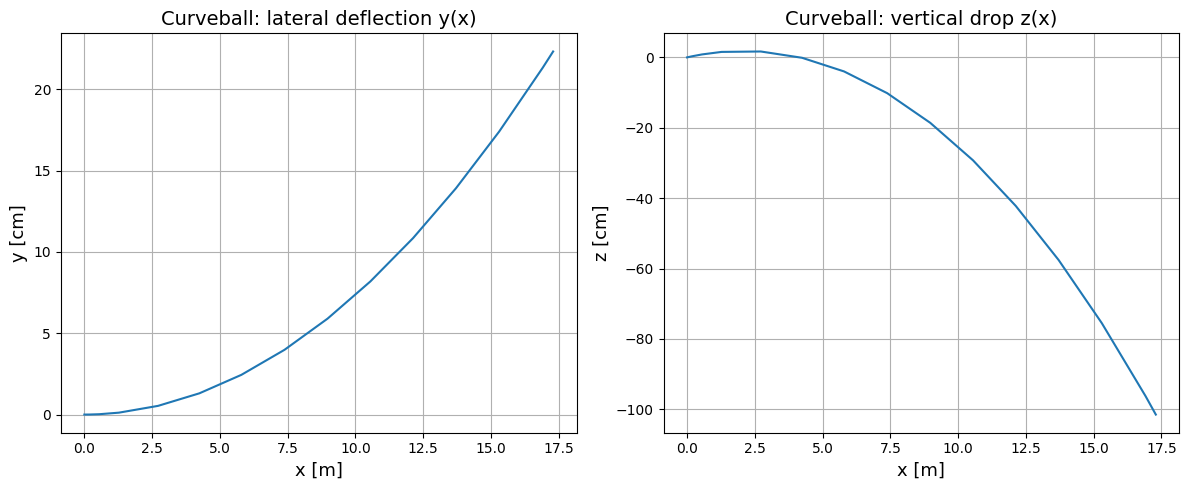

In [6]:
phi_curve = np.radians(45.0)
v0_curve  = 85.0
f_curve   = lambda t, s: baseball_rhs(t, s, OMEGA, phi_curve)
y0_curve  = baseball_ic(v0_curve)
t_curve   = baseball_tend(v0_curve)

ts_c, ys_c, ns_c, nf_c = rk_adaptive(f_curve, 0.0, y0_curve, t_curve,
                                       1e-9, 4, return_trajectory=True)
xs_c  = ys_c[:, 0]
ysc_y = ys_c[:, 1]
zs_c  = ys_c[:, 2]

# Store reference final state for Part 6
ref_curve = ys_c[-1].copy()

print(f"Curveball: {ns_c} steps, {nf_c} f-calls")
print(f"Final: x={xs_c[-1]:.3f} m | y={ysc_y[-1]*100:.2f} cm | z={zs_c[-1]*100:.2f} cm")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(xs_c, ysc_y * 100)
axes[0].set_xlabel('x [m]', fontsize=13)
axes[0].set_ylabel('y [cm]', fontsize=13)
axes[0].set_title('Curveball: lateral deflection y(x)', fontsize=14)
axes[0].grid(True)

axes[1].plot(xs_c, zs_c * 100)
axes[1].set_xlabel('x [m]', fontsize=13)
axes[1].set_ylabel('z [cm]', fontsize=13)
axes[1].set_title('Curveball: vertical drop z(x)', fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Part 5: Fastball Trajectory

$v_0 = 95\,\text{mph}$, $\varphi = 225°$, $\omega = 1800\,\text{rpm}$.  Solved with RK4, tolerance $10^{-9}$.

Fastball: 14 steps, 168 f-calls
Final: x=17.466 m | y=-20.23 cm | z=-37.39 cm


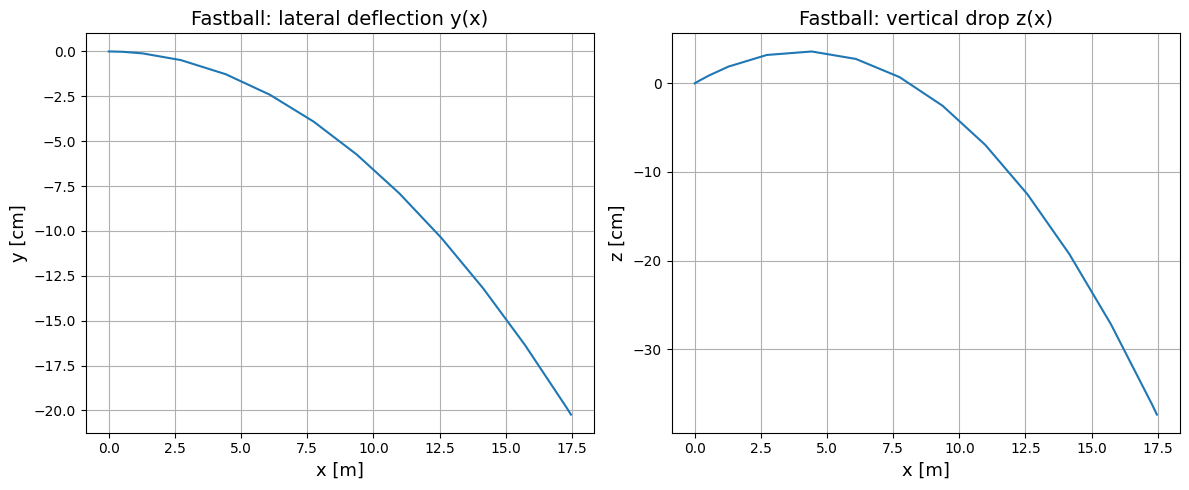

In [7]:
phi_fast = np.radians(225.0)
v0_fast  = 95.0
f_fast   = lambda t, s: baseball_rhs(t, s, OMEGA, phi_fast)
y0_fast  = baseball_ic(v0_fast)
t_fast   = baseball_tend(v0_fast)

ts_f, ys_f, ns_f, nf_f = rk_adaptive(f_fast, 0.0, y0_fast, t_fast,
                                       1e-9, 4, return_trajectory=True)
xs_f  = ys_f[:, 0]
ysf_y = ys_f[:, 1]
zs_f  = ys_f[:, 2]

print(f"Fastball: {ns_f} steps, {nf_f} f-calls")
print(f"Final: x={xs_f[-1]:.3f} m | y={ysf_y[-1]*100:.2f} cm | z={zs_f[-1]*100:.2f} cm")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(xs_f, ysf_y * 100)
axes[0].set_xlabel('x [m]', fontsize=13)
axes[0].set_ylabel('y [cm]', fontsize=13)
axes[0].set_title('Fastball: lateral deflection y(x)', fontsize=14)
axes[0].grid(True)

axes[1].plot(xs_f, zs_f * 100)
axes[1].set_xlabel('x [m]', fontsize=13)
axes[1].set_ylabel('z [cm]', fontsize=13)
axes[1].set_title('Fastball: vertical drop z(x)', fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Part 6: Curveball — Accuracy vs. Computational Cost

Run curveball at tolerances $10^{-1},10^{-3},10^{-5},10^{-7}$ for RK3 and RK4.
$\Delta y$ and $\Delta z$ are differences from the high-accuracy reference (Part 4, RK4, $10^{-9}$).

In [8]:
ref_y = ref_curve[1]   # y position at high accuracy (Part 4)
ref_z = ref_curve[2]   # z position

print(f"{'Order':>7} {'Tol':>8} {'f-calls (baseball)':>20} {'Δy [cm]':>14} {'Δz [cm]':>14}")
print("-" * 67)
for order in (3, 4):
    for tol in (1e-1, 1e-3, 1e-5, 1e-7):
        y_fin, ns, nf = rk_adaptive(f_curve, 0.0, y0_curve, t_curve, tol, order)
        dy = (y_fin[1] - ref_y) * 100
        dz = (y_fin[2] - ref_z) * 100
        print(f"{order:>7} {tol:>8.0e} {nf:>20d} {dy:>14.4e} {dz:>14.4e}")

  Order      Tol   f-calls (baseball)        Δy [cm]        Δz [cm]
-------------------------------------------------------------------
      3    1e-01                   63     1.7257e-06    -1.2899e-05
      3    1e-03                   63     1.7257e-06    -1.2899e-05
      3    1e-05                   72     4.1948e-07    -3.1260e-06
      3    1e-07                  135     6.7305e-09    -4.6995e-08
      4    1e-01                   84     1.4455e-09     6.4250e-09
      4    1e-03                   84     1.4455e-09     6.4250e-09
      4    1e-05                   84     1.4455e-09     6.4250e-09
      4    1e-07                  108    -3.5291e-11     2.6924e-09
